In [16]:
# ---------------------------------------------
# PHASE - 02
# ---------------------------------------------

import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------
# 1. LOAD DATA
# ---------------------------------------------
df = pd.read_csv("card_krueger_full_cleaned.csv")

# ---------------------------------------------
# 2. DATA CLEANING
# ---------------------------------------------
# Remove duplicate stores
df = df.drop_duplicates(subset=['sheet']).copy()

# Construct FTE employment
df['fte_pre'] = df['empft'] + 0.5 * df['emppt']
df['fte_post'] = df['empft2'] + 0.5 * df['emppt2']

# Keep stores with both pre and post observations
df = df.dropna(subset=['fte_pre', 'fte_post']).copy()

# ---------------------------------------------
# 3. CONVERT WIDE DATA TO LONG FORMAT
# ---------------------------------------------
df_long = pd.wide_to_long(
    df,
    stubnames='fte',
    i='sheet',
    j='period',
    sep='_',
    suffix='(pre|post)'
).reset_index()

# Treatment indicator (NJ = 1, PA = 0)
df_long['treat'] = (df_long['state'] == 1).astype(int)

# Post-policy indicator
df_long['post'] = (df_long['period'] == 'post').astype(int)

# Sort values for stability
df_long = df_long.sort_values(['sheet','post'])

# ---------------------------------------------
# 4. DESCRIPTIVE STATISTICS
# ---------------------------------------------
desc_table = df_long.groupby(['treat','post'])['fte'].agg(['mean','std','count'])

print("\n--- Descriptive Statistics (FTE) ---")
print(desc_table)

# ---------------------------------------------
# 5. MANUAL DIFFERENCE-IN-DIFFERENCES (DID)
# ---------------------------------------------
means = df_long.groupby(['treat','post'])['fte'].mean()

nj_after = means[1,1]
nj_before = means[1,0]

pa_after = means[0,1]
pa_before = means[0,0]

nj_diff = nj_after - nj_before
pa_diff = pa_after - pa_before

manual_did = nj_diff - pa_diff

print("\n--- Manual DiD Calculation ---")
print(f"NJ Mean (Pre): {nj_before:.2f} -> (Post): {nj_after:.2f} | Change: {nj_diff:.4f}")
print(f"PA Mean (Pre): {pa_before:.2f} -> (Post): {pa_after:.2f} | Change: {pa_diff:.4f}")
print(f"Difference-in-Differences Estimate: {manual_did:.4f}")

# ---------------------------------------------
# 6. REGRESSION IMPLEMENTATION
# ---------------------------------------------
model = smf.ols("fte ~ treat * post", data=df_long)

results = model.fit(
    cov_type='cluster',
    cov_kwds={'groups': df_long['sheet']}
)

print("\n--- Regression Results (Clustered Standard Errors) ---")
print(results.summary().tables[1])


--- Descriptive Statistics (FTE) ---
                 mean        std  count
treat post                             
0     0     19.742188   9.650440     32
      1      6.320312   5.121600     32
1     0     17.650424  10.873011    118
      1      6.451271   4.407921    118

--- Manual DiD Calculation ---
NJ Mean (Pre): 17.65 -> (Post): 6.45 | Change: -11.1992
PA Mean (Pre): 19.74 -> (Post): 6.32 | Change: -13.4219
Difference-in-Differences Estimate: 2.2227

--- Regression Results (Clustered Standard Errors) ---
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     19.7422      1.693     11.659      0.000      16.423      23.061
treat         -2.0918      1.969     -1.062      0.288      -5.951       1.768
post         -13.4219      1.747     -7.682      0.000     -16.846      -9.997
treat:post     2.2227      1.980      1.123      0.262      -1.658       6.103


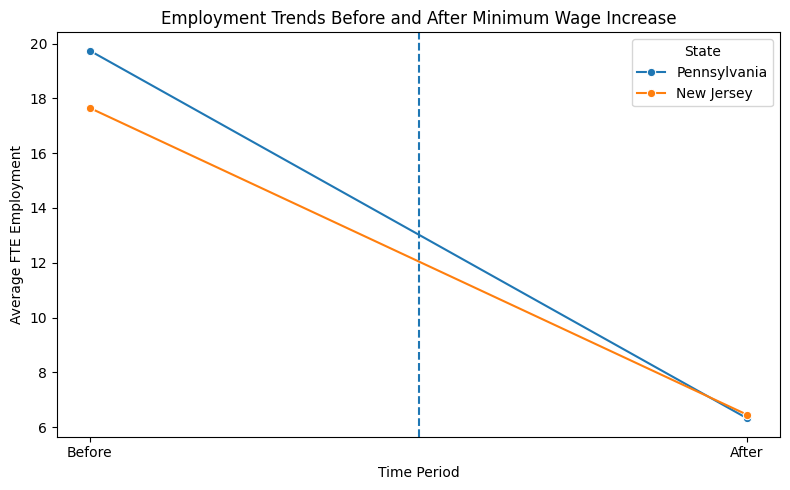

In [17]:
# ---------------------------------------------
# 7. PARALLEL TRENDS VISUALIZATION (OPTONAL)
# ---------------------------------------------
trend = df_long.groupby(['post','treat'])['fte'].mean().reset_index()

trend['State'] = trend['treat'].map({0:'Pennsylvania',1:'New Jersey'})
trend['Period'] = trend['post'].map({0:'Before',1:'After'})

plt.figure(figsize=(8,5))

sns.lineplot(
    data=trend,
    x='Period',
    y='fte',
    hue='State',
    marker='o'
)

plt.axvline(x=0.5, linestyle='--')

plt.title("Employment Trends Before and After Minimum Wage Increase")
plt.xlabel("Time Period")
plt.ylabel("Average FTE Employment")

plt.legend(title="State")
plt.tight_layout()
plt.show()